# Week 4 Capstone Project
## Heart Disease Prediction Using Machine Learning

## Objective

The objective of this project is to predict whether a patient is likely to have heart disease based on medical attributes using Machine Learning.

## Hypothesis

Patients with higher age, cholesterol levels, blood pressure, and chest pain symptoms are more likely to have heart disease.

## Dataset

Dataset: Heart Disease UCI Dataset

Features:
- Age
- Sex
- Chest Pain Type
- Cholesterol
- Resting Blood Pressure
- Maximum Heart Rate
- Exercise Induced Angina
- ST Depression
- Number of Major Vessels

Target Variable:
- 0 = No Heart Disease
- 1 = Heart Disease

## Data Preprocessing

- Loaded dataset using Pandas
- Removed unnecessary columns
- Handled missing values
- Converted categorical data into numerical format
- Applied feature scaling using StandardScaler

In [ ]:
from google.colab import files
uploaded = files.upload()


Saving heart_disease_uci.csv to heart_disease_uci (1).csv


In [ ]:
import pandas as pd

df = pd.read_csv("heart_disease_uci.csv")
print(df.head())

   id  age     sex    dataset               cp  trestbps   chol    fbs  \
0   1   63    Male  Cleveland   typical angina     145.0  233.0   True   
1   2   67    Male  Cleveland     asymptomatic     160.0  286.0  False   
2   3   67    Male  Cleveland     asymptomatic     120.0  229.0  False   
3   4   37    Male  Cleveland      non-anginal     130.0  250.0  False   
4   5   41  Female  Cleveland  atypical angina     130.0  204.0  False   

          restecg  thalch  exang  oldpeak        slope   ca  \
0  lv hypertrophy   150.0  False      2.3  downsloping  0.0   
1  lv hypertrophy   108.0   True      1.5         flat  3.0   
2  lv hypertrophy   129.0   True      2.6         flat  2.0   
3          normal   187.0  False      3.5  downsloping  0.0   
4  lv hypertrophy   172.0  False      1.4    upsloping  0.0   

                thal  num  
0       fixed defect    0  
1             normal    2  
2  reversable defect    1  
3             normal    0  
4             normal    0  


In [ ]:
print(df.columns.tolist())

['id', 'age', 'sex', 'dataset', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num']


/tmp/ipykernel_943/1216692559.py:24: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].fillna(df[col].mode()[0])


Accuracy : 79.89 %
Precision: 85.29 %
Recall   : 79.82 %


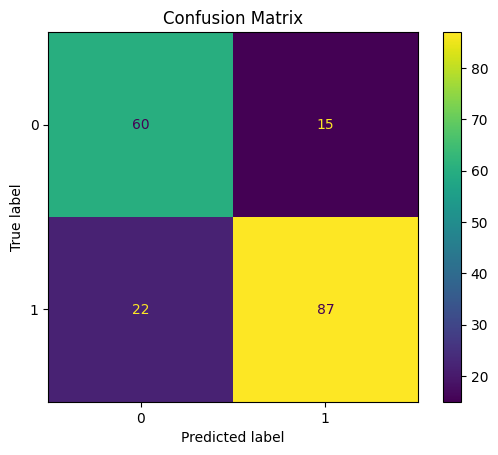

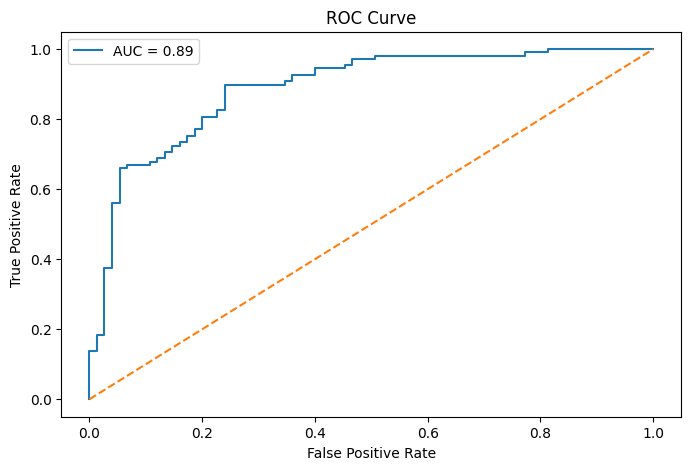

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, roc_auc_score

df = pd.read_csv("heart_disease_uci.csv")

df.drop(['id', 'dataset'], axis=1, inplace=True)

df['num'] = df['num'].apply(lambda x: 0 if x == 0 else 1)
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].fillna(df[col].mode()[0])
    else:
        df[col] = df[col].fillna(df[col].median())
df = pd.get_dummies(df, drop_first=True)
X = df.drop('num', axis=1)
y = df['num']
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

print("Accuracy :", round(accuracy*100,2), "%")
print("Precision:", round(precision*100,2), "%")
print("Recall   :", round(recall*100,2), "%")


cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix")
plt.show()


y_prob = model.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(8,5))
plt.plot(fpr, tpr, label=f"AUC = {auc:.2f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()